✅ Librerías cargadas

📁 Por favor, sube el archivo '2_Accidentes_Mortales_en_Mina.xlsx'


Saving 2_Accidentes_Mortales_en_Mina.xlsx to 2_Accidentes_Mortales_en_Mina.xlsx

✅ Archivo '2_Accidentes_Mortales_en_Mina.xlsx' subido correctamente.
Shape: (901, 9)

Columnas: ['TITULAR', 'UNIDAD', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'TIPO_ACCIDENTE', 'CATEGORIA', 'FECHA_ACCIDENTE', 'FECHA_FALLECIMIENTO']

Primeras filas:

=== VALORES NULOS ===
TITULAR                 0
UNIDAD                  0
DEPARTAMENTO            2
PROVINCIA               2
DISTRITO                2
TIPO_ACCIDENTE          0
CATEGORIA              68
FECHA_ACCIDENTE         0
FECHA_FALLECIMIENTO     0
dtype: int64

=== TIPOS DE DATO ===
TITULAR                object
UNIDAD                 object
DEPARTAMENTO           object
PROVINCIA              object
DISTRITO               object
TIPO_ACCIDENTE         object
CATEGORIA              object
FECHA_ACCIDENTE        object
FECHA_FALLECIMIENTO    object
dtype: object

=== CATEGORÍAS ÚNICAS ===
CATEGORIA: 4 únicos
CATEGORIA
Gran y Mediana Minería    742
NaN   

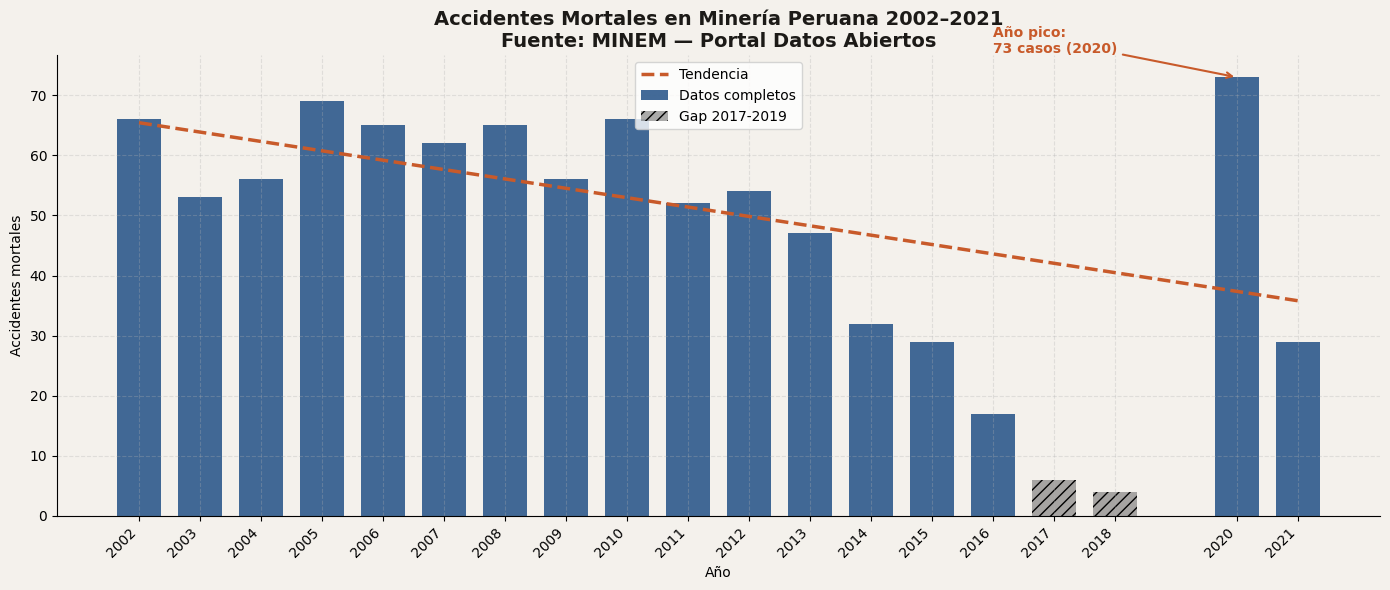

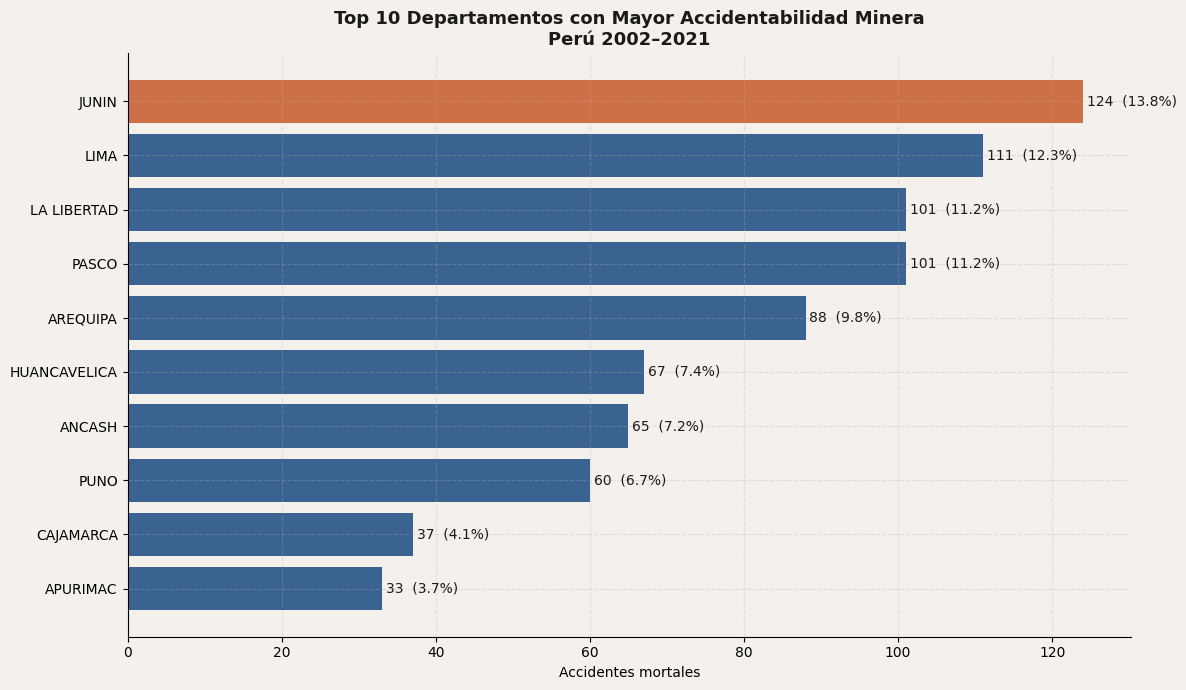

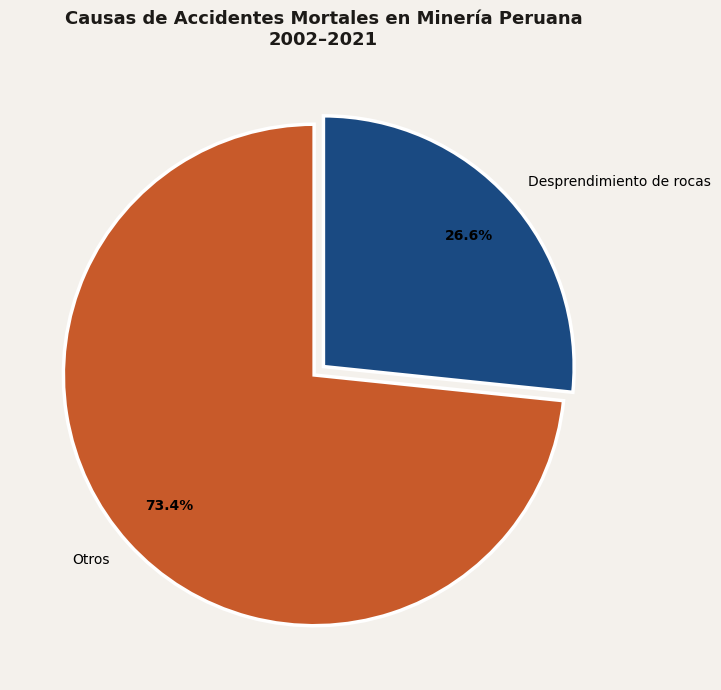

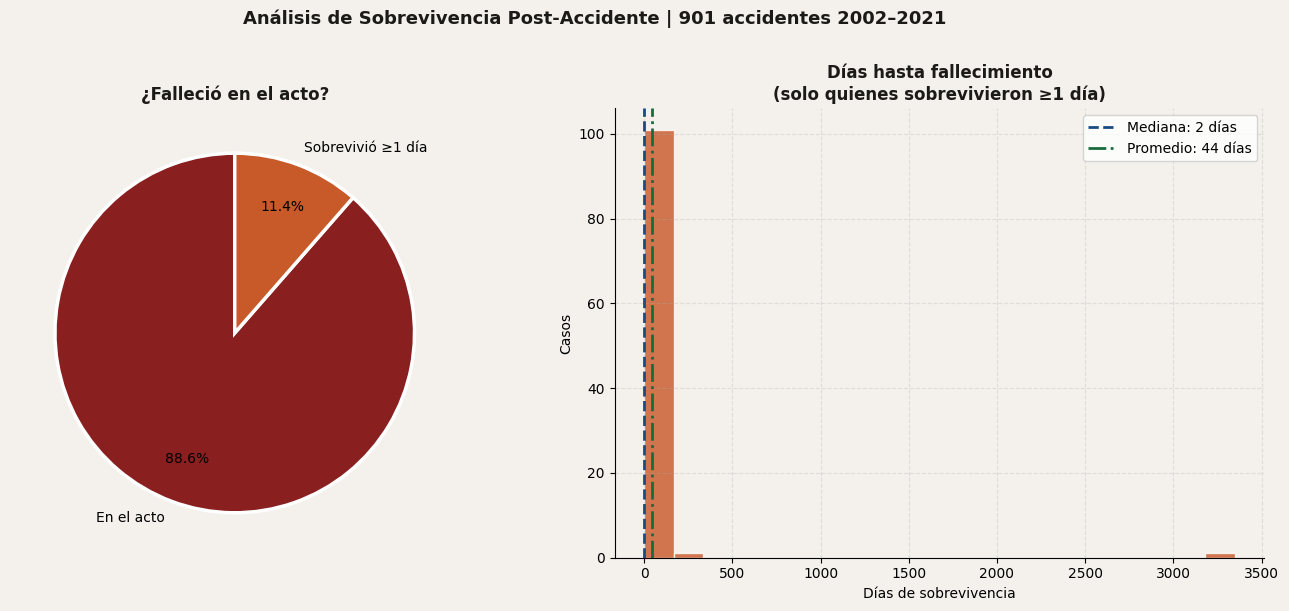

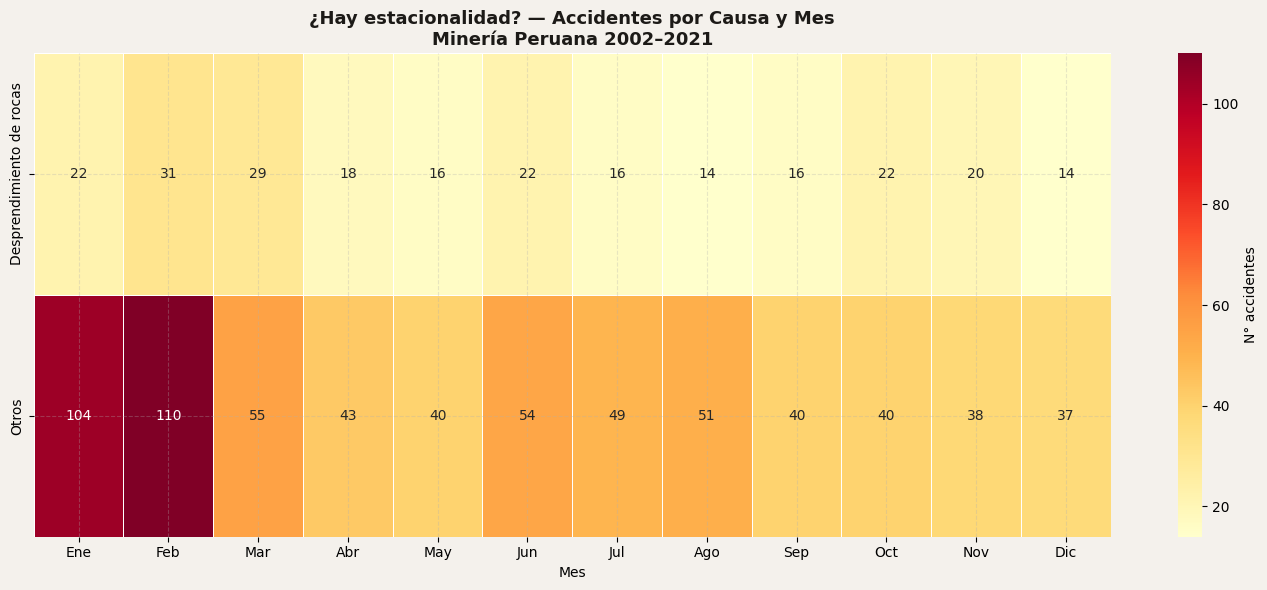

✅ CSV exportado: outputs/accidentes_limpio_para_powerbi.csv
   901 filas × 14 columnas


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


   HALLAZGOS PARA EL POST DE LINKEDIN
   Total accidentes analizados : 901
   Período                     : 2002 – 2021
   Año pico                    : 2020 (73 casos)
   Reducción desde el pico     : 60% menos
   Departamento más afectado   : JUNIN
   Causa principal             : Otros (661 casos)
   Fallecieron en el acto (0d) : 798 (89%)
   Sobrevivieron ≥ 1 día       : 103
   Caso extremo                : 3348 días (9.2 años)

🎉 Todo listo. Revisa la carpeta 'outputs/' para imágenes y el CSV descargado.


In [1]:
# ──────────────────────────────────────────────────────────────────────────────
#  INSTALACIÓN DE LIBRERÍAS (solo necesario en Colab)
# ──────────────────────────────────────────────────────────────────────────────
!pip install openpyxl seaborn -q

# ──────────────────────────────────────────────────────────────────────────────
#  IMPORTS
# ──────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from google.colab import files   # Para subir archivos y descargar resultados

warnings.filterwarnings('ignore')

# Paleta de colores del proyecto
ORANGE = '#C85A2A'
BLUE   = '#1A4A82'
GREEN  = '#1A6B3C'
RED    = '#8A1F1F'
GRAY   = '#595959'
LGRAY  = '#F4F1EC'
DARK   = '#1C1A17'
COLORS = [ORANGE, BLUE, GREEN, RED, '#5B3FA6', '#0A6E62', '#A86E0A']

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

os.makedirs('outputs', exist_ok=True)
print('✅ Librerías cargadas')

# ──────────────────────────────────────────────────────────────────────────────
#  PASO 0 — SUBIR EL ARCHIVO EXCEL (INTERACTIVO)
# ──────────────────────────────────────────────────────────────────────────────
print("\n📁 Por favor, sube el archivo '2_Accidentes_Mortales_en_Mina.xlsx'")
uploaded = files.upload()

# Obtener el nombre del archivo subido (asumimos que es el único)
filename = list(uploaded.keys())[0]
print(f"\n✅ Archivo '{filename}' subido correctamente.")

# ──────────────────────────────────────────────────────────────────────────────
#  PASO 1 — CARGA Y DIAGNÓSTICO
# ──────────────────────────────────────────────────────────────────────────────
df_raw = pd.read_excel(filename)

print(f'Shape: {df_raw.shape}')
print(f'\nColumnas: {df_raw.columns.tolist()}')
print(f'\nPrimeras filas:')
df_raw.head()

# Diagnóstico de calidad
print('\n=== VALORES NULOS ===')
print(df_raw.isnull().sum())

print('\n=== TIPOS DE DATO ===')
print(df_raw.dtypes)

print('\n=== CATEGORÍAS ÚNICAS ===')
for col in ['CATEGORIA', 'TIPO_ACCIDENTE', 'DEPARTAMENTO']:
    if col in df_raw.columns:
        print(f'{col}: {df_raw[col].nunique()} únicos')
        print(df_raw[col].value_counts(dropna=False).head(8))
        print()

# Detección de fechas inconsistentes
df_check = df_raw.copy()
df_check['FECHA_ACCIDENTE']     = pd.to_datetime(df_check['FECHA_ACCIDENTE'], dayfirst=True, errors='coerce')
df_check['FECHA_FALLECIMIENTO'] = pd.to_datetime(df_check['FECHA_FALLECIMIENTO'], dayfirst=True, errors='coerce')
df_check['DIAS'] = (df_check['FECHA_FALLECIMIENTO'] - df_check['FECHA_ACCIDENTE']).dt.days

print(f'Fechas con FALLECIMIENTO antes del ACCIDENTE: {(df_check["DIAS"] < 0).sum()}')
print('\nEjemplos de fechas inconsistentes:')
df_check[df_check['DIAS'] < 0][['FECHA_ACCIDENTE', 'FECHA_FALLECIMIENTO', 'DIAS']].head(5)

# ──────────────────────────────────────────────────────────────────────────────
#  PASO 2 — LIMPIEZA DOCUMENTADA
# ──────────────────────────────────────────────────────────────────────────────
df = df_raw.copy()

# 1. Parsear fechas
df['FECHA_ACCIDENTE']     = pd.to_datetime(df['FECHA_ACCIDENTE'], dayfirst=True, errors='coerce')
df['FECHA_FALLECIMIENTO'] = pd.to_datetime(df['FECHA_FALLECIMIENTO'], dayfirst=True, errors='coerce')
df['AÑO'] = df['FECHA_ACCIDENTE'].dt.year
df['MES'] = df['FECHA_ACCIDENTE'].dt.month

# 2. Calcular días de sobrevivencia
df['DIAS_SOBREVIVENCIA'] = (df['FECHA_FALLECIMIENTO'] - df['FECHA_ACCIDENTE']).dt.days

# 3. CORRECCIÓN: fechas negativas → 0
n_neg = (df['DIAS_SOBREVIVENCIA'] < 0).sum()
df.loc[df['DIAS_SOBREVIVENCIA'] < 0, 'DIAS_SOBREVIVENCIA'] = 0
print(f'✔ {n_neg} fechas negativas corregidas → 0 días')

# 4. CORRECCIÓN: nulos en CATEGORIA
n_nulos = df['CATEGORIA'].isna().sum()
df['CATEGORIA'] = df['CATEGORIA'].fillna('Sin Información')
df.loc[df['CATEGORIA'] == 'Sin Categoría', 'CATEGORIA'] = 'Sin Información'
print(f'✔ {n_nulos} nulos en CATEGORIA → Sin Información')

# 5. CORRECCIÓN: nulos en DEPARTAMENTO
df['DEPARTAMENTO'] = df['DEPARTAMENTO'].fillna('Sin Información')
print(f'✔ Nulos en DEPARTAMENTO corregidos')

print(f'\n✅ Dataset limpio: {df.shape[0]} filas × {df.shape[1]} columnas')

# ──────────────────────────────────────────────────────────────────────────────
#  PASO 3 — FEATURE ENGINEERING
# ──────────────────────────────────────────────────────────────────────────────
meses_es = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
            7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
df['MES_NOMBRE'] = df['MES'].map(meses_es)
df['TRIMESTRE']  = df['MES'].apply(lambda x: f"T{((x-1)//3)+1}")

df['FALLECIÓ_EN_ACTO'] = df['DIAS_SOBREVIVENCIA'].apply(
    lambda x: 'En el acto' if x == 0 else 'Sobrevivió ≥1 día')

causa_map = {
    'DESPRENDIMIENTO DE ROCAS': 'Desprendimiento de rocas',
    'CAÍDA DE ROCAS':           'Desprendimiento de rocas',
    'EXPLOSIÓN':                'Explosión / Voladuras',
    'EXPLOSIVOS':               'Explosión / Voladuras',
    'CAÍDA DE PERSONAS':        'Caídas',
    'CAIDA DE PERSONAS':        'Caídas',
    'CAÍDA DE OBJETOS':         'Caídas',
    'INTOXICACIÓN':             'Intoxicación / Gases',
    'DERRUMBE':                 'Derrumbe / Deslizamiento',
    'APLASTAMIENTO':            'Aplastamiento / Golpe',
    'GOLPE / APLASTAMIENTO':    'Aplastamiento / Golpe',
}
df['CAUSA_AGRUPADA'] = df['TIPO_ACCIDENTE'].map(causa_map).fillna('Otros')

def region_macro(dep):
    norte  = ['CAJAMARCA','LA LIBERTAD','ANCASH','LAMBAYEQUE','PIURA','AMAZONAS']
    centro = ['JUNIN','PASCO','LIMA','HUANUCO','HUANCAVELICA','LORETO','UCAYALI']
    sur    = ['AREQUIPA','CUSCO','PUNO','MOQUEGUA','TACNA','APURIMAC','AYACUCHO','ICA']
    d = str(dep).upper()
    if d in norte:  return 'Norte'
    if d in centro: return 'Centro'
    if d in sur:    return 'Sur'
    return 'Oriente'

df['REGION_MACRO'] = df['DEPARTAMENTO'].apply(region_macro)

df['NOTA_GAP'] = df['AÑO'].apply(
    lambda x: 'Período transición sistema reporte MINEM' if x in [2017,2018,2019] else '')

print(f'✅ Columnas nuevas creadas: MES_NOMBRE, TRIMESTRE, FALLECIÓ_EN_ACTO,')
print(f'   CAUSA_AGRUPADA, REGION_MACRO, NOTA_GAP')
print(f'\nDataset final: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head(3)

# ──────────────────────────────────────────────────────────────────────────────
#  PASO 4 — VISUALIZACIONES (se guardan en outputs/)
# ──────────────────────────────────────────────────────────────────────────────
# Gráfico 1: Tendencia anual
anual = df.groupby('AÑO').size().reset_index(name='Accidentes')
anual_ok  = anual[~anual['AÑO'].isin([2017,2018,2019])]
anual_gap = anual[ anual['AÑO'].isin([2017,2018,2019])]

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(LGRAY); ax.set_facecolor(LGRAY)

ax.bar(anual_ok['AÑO'],  anual_ok['Accidentes'],  color=BLUE, alpha=0.82, width=0.72, label='Datos completos')
ax.bar(anual_gap['AÑO'], anual_gap['Accidentes'], color=GRAY, alpha=0.5,  width=0.72, hatch='///', label='Gap 2017-2019')

coeffs = np.polyfit(anual_ok['AÑO'].values, anual_ok['Accidentes'].values, 1)
ax.plot(anual_ok['AÑO'], np.polyval(coeffs, anual_ok['AÑO']), color=ORANGE, lw=2.5, ls='--', label='Tendencia')

pico = anual.loc[anual['Accidentes'].idxmax()]
ax.annotate(f"Año pico:\n{int(pico['Accidentes'])} casos ({int(pico['AÑO'])})",
            xy=(pico['AÑO'], pico['Accidentes']),
            xytext=(pico['AÑO']-4, pico['Accidentes']+4),
            arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.5),
            fontsize=10, color=ORANGE, fontweight='bold')

ax.set_title('Accidentes Mortales en Minería Peruana 2002–2021\nFuente: MINEM — Portal Datos Abiertos', fontsize=14, fontweight='bold', color=DARK)
ax.set_xlabel('Año'); ax.set_ylabel('Accidentes mortales')
ax.set_xticks(anual['AÑO']); ax.set_xticklabels(anual['AÑO'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/01_tendencia_anual.png', dpi=150, bbox_inches='tight', facecolor=LGRAY)
plt.show()

# Gráfico 2: Top departamentos
dept = df[df['DEPARTAMENTO'] != 'Sin Información'].groupby('DEPARTAMENTO').size().sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(LGRAY); ax.set_facecolor(LGRAY)
cols_d = [ORANGE if i == len(dept)-1 else BLUE for i in range(len(dept))]
bars = ax.barh(dept.index, dept.values, color=cols_d, alpha=0.85)
for bar, v in zip(bars, dept.values):
    ax.text(v + 0.5, bar.get_y() + bar.get_height()/2,
            f'{v}  ({v/len(df)*100:.1f}%)', va='center', fontsize=10, color=DARK)
ax.set_title('Top 10 Departamentos con Mayor Accidentabilidad Minera\nPerú 2002–2021', fontsize=13, fontweight='bold', color=DARK)
ax.set_xlabel('Accidentes mortales')
plt.tight_layout()
plt.savefig('outputs/02_departamentos.png', dpi=150, bbox_inches='tight', facecolor=LGRAY)
plt.show()

# Gráfico 3: Causas
causas_v = df['CAUSA_AGRUPADA'].value_counts()
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(LGRAY); ax.set_facecolor(LGRAY)
explode = [0.05 if i == 0 else 0 for i in range(len(causas_v))]
wedges, texts, pcts = ax.pie(causas_v.values, labels=causas_v.index,
    autopct='%1.1f%%', colors=COLORS[:len(causas_v)],
    startangle=90, explode=explode, pctdistance=0.78,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5})
for t in pcts: t.set_fontsize(10); t.set_fontweight('bold')
ax.set_title('Causas de Accidentes Mortales en Minería Peruana\n2002–2021', fontsize=13, fontweight='bold', color=DARK)
plt.tight_layout()
plt.savefig('outputs/03_causas.png', dpi=150, bbox_inches='tight', facecolor=LGRAY)
plt.show()

# Gráfico 4: Sobrevivencia
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(LGRAY)

sv = df['FALLECIÓ_EN_ACTO'].value_counts()
axes[0].set_facecolor(LGRAY)
axes[0].pie(sv.values, labels=sv.index, autopct='%1.1f%%',
    colors=[RED, ORANGE], startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5}, pctdistance=0.75)
axes[0].set_title('¿Falleció en el acto?', fontweight='bold', fontsize=12, color=DARK)

sobrev = df[df['DIAS_SOBREVIVENCIA'] > 0]['DIAS_SOBREVIVENCIA']
axes[1].set_facecolor(LGRAY)
axes[1].hist(sobrev, bins=20, color=ORANGE, alpha=0.82, edgecolor='white')
axes[1].axvline(sobrev.median(), color=BLUE, lw=2, ls='--', label=f'Mediana: {sobrev.median():.0f} días')
axes[1].axvline(sobrev.mean(),   color=GREEN, lw=2, ls='-.', label=f'Promedio: {sobrev.mean():.0f} días')
axes[1].set_title('Días hasta fallecimiento\n(solo quienes sobrevivieron ≥1 día)', fontweight='bold', fontsize=12, color=DARK)
axes[1].set_xlabel('Días de sobrevivencia'); axes[1].set_ylabel('Casos')
axes[1].legend()

plt.suptitle('Análisis de Sobrevivencia Post-Accidente | 901 accidentes 2002–2021',
             fontsize=13, fontweight='bold', color=DARK, y=1.01)
plt.tight_layout()
plt.savefig('outputs/04_sobrevivencia.png', dpi=150, bbox_inches='tight', facecolor=LGRAY)
plt.show()

# Gráfico 5: Heatmap
orden_meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
pivot = df.pivot_table(index='CAUSA_AGRUPADA', columns='MES_NOMBRE',
                       values='AÑO', aggfunc='count', fill_value=0)
pivot = pivot.reindex(columns=[m for m in orden_meses if m in pivot.columns])

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(LGRAY)
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=True, fmt='d',
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'N° accidentes'})
ax.set_title('¿Hay estacionalidad? — Accidentes por Causa y Mes\nMinería Peruana 2002–2021',
             fontsize=13, fontweight='bold', color=DARK)
ax.set_xlabel('Mes'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig('outputs/05_heatmap.png', dpi=150, bbox_inches='tight', facecolor=LGRAY)
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
#  PASO 5 — EXPORTAR CSV LIMPIO Y DESCARGARLO
# ──────────────────────────────────────────────────────────────────────────────
cols_export = [
    'FECHA_ACCIDENTE', 'FECHA_FALLECIMIENTO', 'AÑO', 'MES', 'MES_NOMBRE',
    'TRIMESTRE', 'DEPARTAMENTO', 'REGION_MACRO', 'CATEGORIA',
    'TIPO_ACCIDENTE', 'CAUSA_AGRUPADA', 'DIAS_SOBREVIVENCIA',
    'FALLECIÓ_EN_ACTO', 'NOTA_GAP'
]

df[cols_export].to_csv('outputs/accidentes_limpio_para_powerbi.csv',
                        index=False, encoding='utf-8-sig')

print('✅ CSV exportado: outputs/accidentes_limpio_para_powerbi.csv')
print(f'   {len(df)} filas × {len(cols_export)} columnas')

# Descargar el CSV a tu computadora
files.download('outputs/accidentes_limpio_para_powerbi.csv')

# ──────────────────────────────────────────────────────────────────────────────
#  PASO 6 — HALLAZGOS CLAVE
# ──────────────────────────────────────────────────────────────────────────────
anual = df.groupby('AÑO').size().reset_index(name='Accidentes')
pico  = anual.loc[anual['Accidentes'].idxmax()]
ult   = anual[anual['AÑO'] == anual['AÑO'].max()]['Accidentes'].values[0]
sobrev_pos = df[df['DIAS_SOBREVIVENCIA'] > 0]

print('\n' + '=' * 55)
print('   HALLAZGOS PARA EL POST DE LINKEDIN')
print('=' * 55)
print(f"   Total accidentes analizados : {len(df)}")
print(f"   Período                     : {int(df['AÑO'].min())} – {int(df['AÑO'].max())}")
print(f"   Año pico                    : {int(pico['AÑO'])} ({int(pico['Accidentes'])} casos)")
print(f"   Reducción desde el pico     : {round((1-ult/pico['Accidentes'])*100)}% menos")
print(f"   Departamento más afectado   : {df[df['DEPARTAMENTO']!='Sin Información']['DEPARTAMENTO'].value_counts().index[0]}")
print(f"   Causa principal             : {df['CAUSA_AGRUPADA'].value_counts().index[0]} ({df['CAUSA_AGRUPADA'].value_counts().iloc[0]} casos)")
print(f"   Fallecieron en el acto (0d) : {(df['DIAS_SOBREVIVENCIA']==0).sum()} ({(df['DIAS_SOBREVIVENCIA']==0).sum()/len(df)*100:.0f}%)")
print(f"   Sobrevivieron ≥ 1 día       : {len(sobrev_pos)}")
print(f"   Caso extremo                : {int(df['DIAS_SOBREVIVENCIA'].max())} días ({df['DIAS_SOBREVIVENCIA'].max()/365:.1f} años)")
print('=' * 55)

print("\n🎉 Todo listo. Revisa la carpeta 'outputs/' para imágenes y el CSV descargado.")